# Google Trending Now Analysis - India 2026

## Introduction

This analysis examines Google's currently trending searches in India using Google Trends Trending Now data.

Unlike the historical keyword analysis, Trending Now focuses on search queries experiencing a recent increase in search interest.

The objective is to identify current trending topics, examine search volumes, and understand the types of topics attracting attention in India.

## 1. Importing Libraries

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Loading the Dataset

In [28]:
trending_df = pd.read_csv("../data/raw/trending_now_india_2026.csv")

trending_df.head()

,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
0,south africa vs australia,500K+,"September 24, 2026 at 12:30:00 PM UTC+5:30",NaN,"south africa vs australia,sa vs aus,aus vs sa,...",./explore?q=south%20africa%20vs%20australia&ge...
1,afghanistan vs japan,500K+,"September 24, 2026 at 4:40:00 AM UTC+5:30",NaN,"afghanistan vs japan,darwish rasooli,afg vs japan",./explore?q=afghanistan%20vs%20japan&geo=IN
2,weather tomorrow,500K+,"September 24, 2026 at 9:00:00 PM UTC+5:30","September 24, 2026 at 10:30:00 PM UTC+5:30",weather tomorrow,./explore?q=weather%20tomorrow&geo=IN
3,कल का मौसम,200K+,"September 24, 2026 at 8:50:00 PM UTC+5:30","September 24, 2026 at 10:30:00 PM UTC+5:30","कल का मौसम,mausam,बारिश",./explore?q=%E0%A4%95%E0%A4%B2%20%E0%A4%95%E0%...
4,sri lanka vs england,200K+,"September 24, 2026 at 5:10:00 PM UTC+5:30","September 24, 2026 at 9:40:00 PM UTC+5:30",sri lanka vs england,./explore?q=sri%20lanka%20vs%20england&geo=IN


## 3. Understanding the Dataset

In [29]:
trending_df.shape

(94, 6)

In [30]:
trending_df.columns

Index(['Trends', 'Search volume', 'Started', 'Ended', 'Trend breakdown',
       'Explore link'],
      dtype='object')

In [31]:
trending_df.head(10)

,Trends,Search volume,Started,Ended,Trend breakdown,Explore link
0,south africa vs australia,500K+,"September 24, 2026 at 12:30:00 PM UTC+5:30",NaN,"south africa vs australia,sa vs aus,aus vs sa,...",./explore?q=south%20africa%20vs%20australia&ge...
1,afghanistan vs japan,500K+,"September 24, 2026 at 4:40:00 AM UTC+5:30",NaN,"afghanistan vs japan,darwish rasooli,afg vs japan",./explore?q=afghanistan%20vs%20japan&geo=IN
2,weather tomorrow,500K+,"September 24, 2026 at 9:00:00 PM UTC+5:30","September 24, 2026 at 10:30:00 PM UTC+5:30",weather tomorrow,./explore?q=weather%20tomorrow&geo=IN
3,कल का मौसम,200K+,"September 24, 2026 at 8:50:00 PM UTC+5:30","September 24, 2026 at 10:30:00 PM UTC+5:30","कल का मौसम,mausam,बारिश",./explore?q=%E0%A4%95%E0%A4%B2%20%E0%A4%95%E0%...
4,sri lanka vs england,200K+,"September 24, 2026 at 5:10:00 PM UTC+5:30","September 24, 2026 at 9:40:00 PM UTC+5:30",sri lanka vs england,./explore?q=sri%20lanka%20vs%20england&geo=IN
5,kusal mendis,100K+,"September 24, 2026 at 5:50:00 PM UTC+5:30",NaN,"kusal mendis,kamindu mendis,tom banton,sri lan...",./explore?q=kusal%20mendis&geo=IN
6,nse share price,100K+,"September 24, 2026 at 9:10:00 AM UTC+5:30",NaN,"nse share price,nse stock,nse stock ipo,nse,ns...",./explore?q=nse%20share%20price&geo=IN
7,neet pg result 2026,50K+,"September 24, 2026 at 12:50:00 PM UTC+5:30",NaN,"neet pg result 2026,nbems,neet pg,neet pg 2026...",./explore?q=neet%20pg%20result%202026&geo=IN
8,south africa national cricket team vs australi...,50K+,"September 24, 2026 at 1:10:00 PM UTC+5:30","September 24, 2026 at 10:30:00 PM UTC+5:30",south africa national cricket team vs australi...,./explore?q=south%20africa%20national%20cricke...
9,lottery sambad,50K+,"September 24, 2026 at 1:50:00 PM UTC+5:30","September 24, 2026 at 9:20:00 PM UTC+5:30","lottery sambad,dear lottery,nagaland state lot...",./explore?q=lottery%20sambad&geo=IN


In [32]:
trending_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Trends           94 non-null     object
 1   Search volume    94 non-null     object
 2   Started          94 non-null     object
 3   Ended            71 non-null     object
 4   Trend breakdown  94 non-null     object
 5   Explore link     94 non-null     object
dtypes: object(6)
memory usage: 4.5+ KB


In [33]:
trending_df.isnull().sum()

Trends              0
Search volume       0
Started             0
Ended              23
Trend breakdown     0
Explore link        0
dtype: int64

## 4. Data Cleaning

The Trending Now dataset contains search-volume values in text format and timestamp columns stored as strings. These columns are converted into suitable formats for analysis.

In [34]:
trending_df["Started"] = pd.to_datetime(
    trending_df["Started"],
    errors="coerce"
)

trending_df["Ended"] = pd.to_datetime(
    trending_df["Ended"],
    errors="coerce"
)

trending_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype                    
---  ------           --------------  -----                    
 0   Trends           94 non-null     object                   
 1   Search volume    94 non-null     object                   
 2   Started          94 non-null     datetime64[ns, UTC-05:30]
 3   Ended            71 non-null     datetime64[ns, UTC-05:30]
 4   Trend breakdown  94 non-null     object                   
 5   Explore link     94 non-null     object                   
dtypes: datetime64[ns, UTC-05:30](2), object(4)
memory usage: 4.5+ KB


/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/2847579693.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trending_df["Started"] = pd.to_datetime(
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/2847579693.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trending_df["Ended"] = pd.to_datetime(


In [35]:
def convert_search_volume(value):
    value = str(value).replace("+", "").strip()

    if value.endswith("K"):
        return float(value[:-1]) * 1_000
    elif value.endswith("M"):
        return float(value[:-1]) * 1_000_000
    else:
        return float(value)

In [36]:
trending_df["Search Volume Numeric"] = (
    trending_df["Search volume"]
    .apply(convert_search_volume)
)

In [37]:
trending_df[
    ["Trends", "Search volume", "Search Volume Numeric"]
].head(10)

,Trends,Search volume,Search Volume Numeric
0,south africa vs australia,500K+,500000.0
1,afghanistan vs japan,500K+,500000.0
2,weather tomorrow,500K+,500000.0
3,कल का मौसम,200K+,200000.0
4,sri lanka vs england,200K+,200000.0
5,kusal mendis,100K+,100000.0
6,nse share price,100K+,100000.0
7,neet pg result 2026,50K+,50000.0
8,south africa national cricket team vs australi...,50K+,50000.0
9,lottery sambad,50K+,50000.0


In [38]:
trending_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   Trends                 94 non-null     object                   
 1   Search volume          94 non-null     object                   
 2   Started                94 non-null     datetime64[ns, UTC-05:30]
 3   Ended                  71 non-null     datetime64[ns, UTC-05:30]
 4   Trend breakdown        94 non-null     object                   
 5   Explore link           94 non-null     object                   
 6   Search Volume Numeric  94 non-null     float64                  
dtypes: datetime64[ns, UTC-05:30](2), float64(1), object(4)
memory usage: 5.3+ KB


In [39]:
trending_df.head()

,Trends,Search volume,Started,Ended,Trend breakdown,Explore link,Search Volume Numeric
0,south africa vs australia,500K+,2026-09-24 12:30:00-05:30,NaT,"south africa vs australia,sa vs aus,aus vs sa,...",./explore?q=south%20africa%20vs%20australia&ge...,500000.0
1,afghanistan vs japan,500K+,2026-09-24 04:40:00-05:30,NaT,"afghanistan vs japan,darwish rasooli,afg vs japan",./explore?q=afghanistan%20vs%20japan&geo=IN,500000.0
2,weather tomorrow,500K+,2026-09-24 21:00:00-05:30,2026-09-24 22:30:00-05:30,weather tomorrow,./explore?q=weather%20tomorrow&geo=IN,500000.0
3,कल का मौसम,200K+,2026-09-24 20:50:00-05:30,2026-09-24 22:30:00-05:30,"कल का मौसम,mausam,बारिश",./explore?q=%E0%A4%95%E0%A4%B2%20%E0%A4%95%E0%...,200000.0
4,sri lanka vs england,200K+,2026-09-24 17:10:00-05:30,2026-09-24 21:40:00-05:30,sri lanka vs england,./explore?q=sri%20lanka%20vs%20england&geo=IN,200000.0


In [40]:
trending_df["Search Volume Numeric"].describe()

count        94.000000
mean      28563.829787
std       92053.912267
min         200.000000
25%        1000.000000
50%        2000.000000
75%       10000.000000
max      500000.000000
Name: Search Volume Numeric, dtype: float64

## 5. Top Trending Searches

This section identifies the searches with the highest reported search-volume ranges in the Google Trends Trending Now dataset.

In [41]:
top_trends = trending_df.sort_values(
    "Search Volume Numeric",
    ascending=False
)

top_trends[
    ["Trends", "Search volume", "Started", "Ended"]
].head(10)

,Trends,Search volume,Started,Ended
0,south africa vs australia,500K+,2026-09-24 12:30:00-05:30,NaT
2,weather tomorrow,500K+,2026-09-24 21:00:00-05:30,2026-09-24 22:30:00-05:30
1,afghanistan vs japan,500K+,2026-09-24 04:40:00-05:30,NaT
3,कल का मौसम,200K+,2026-09-24 20:50:00-05:30,2026-09-24 22:30:00-05:30
4,sri lanka vs england,200K+,2026-09-24 17:10:00-05:30,2026-09-24 21:40:00-05:30
5,kusal mendis,100K+,2026-09-24 17:50:00-05:30,NaT
6,nse share price,100K+,2026-09-24 09:10:00-05:30,NaT
7,neet pg result 2026,50K+,2026-09-24 12:50:00-05:30,NaT
8,south africa national cricket team vs australi...,50K+,2026-09-24 13:10:00-05:30,2026-09-24 22:30:00-05:30
9,lottery sambad,50K+,2026-09-24 13:50:00-05:30,2026-09-24 21:20:00-05:30


### Top 10 Trending Searches by Search Volume

/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/514396153.py:19: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/514396153.py:19: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/514396153.py:19: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/514396153.py:19: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/514396153.py:19: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/5143

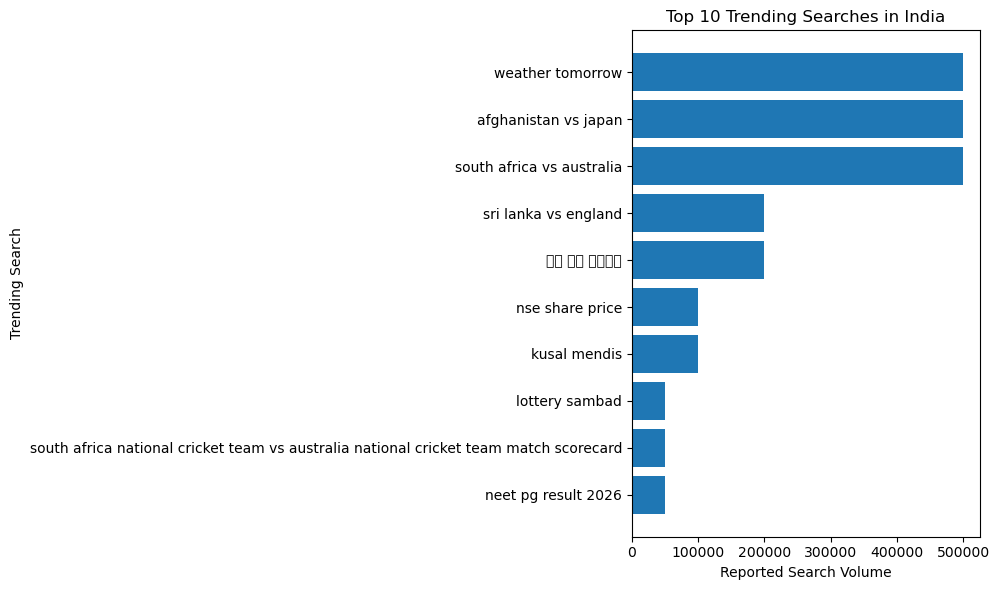

In [42]:
top_10 = trending_df.nlargest(
    10,
    "Search Volume Numeric"
).sort_values(
    "Search Volume Numeric"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Trends"],
    top_10["Search Volume Numeric"]
)

plt.title("Top 10 Trending Searches in India")
plt.xlabel("Reported Search Volume")
plt.ylabel("Trending Search")

plt.tight_layout()
plt.show()

In [43]:
active_trends = trending_df[trending_df["Ended"].isna()]

print("Number of active trends:", len(active_trends))

Number of active trends: 23


In [44]:
active_trends[
    ["Trends", "Search volume", "Started"]
].head(10)

,Trends,Search volume,Started
0,south africa vs australia,500K+,2026-09-24 12:30:00-05:30
1,afghanistan vs japan,500K+,2026-09-24 04:40:00-05:30
5,kusal mendis,100K+,2026-09-24 17:50:00-05:30
6,nse share price,100K+,2026-09-24 09:10:00-05:30
7,neet pg result 2026,50K+,2026-09-24 12:50:00-05:30
11,२४ सितम्बर,20K+,2026-09-24 08:50:00-05:30
12,west indies vs zimbabwe,20K+,2026-09-24 12:50:00-05:30
13,jack edwards,20K+,2026-09-24 13:10:00-05:30
20,vr glasses,10K+,2026-09-24 11:00:00-05:30
21,দীঘা,10K+,2026-09-24 21:10:00-05:30


In [45]:
ended_trends = trending_df.dropna(subset=["Ended"]).copy()

ended_trends["Duration_Hours"] = (
    ended_trends["Ended"] - ended_trends["Started"]
).dt.total_seconds() / 3600

ended_trends[
    ["Trends", "Duration_Hours"]
].head(10)

,Trends,Duration_Hours
2,weather tomorrow,1.500000
3,कल का मौसम,1.666667
4,sri lanka vs england,4.500000
8,south africa national cricket team vs australi...,9.333333
9,lottery sambad,7.500000
10,weather today,3.833333
14,wasim akram,17.333333
15,hong kong vs malaysia,6.833333
16,arab gul,15.166667
17,अफ़ग़ानिस्तान बनाम जापान,6.000000


In [46]:
longest_trends = ended_trends.nlargest(
    10,
    "Duration_Hours"
)

longest_trends[
    ["Trends", "Duration_Hours", "Search volume"]
]

,Trends,Duration_Hours,Search volume
14,wasim akram,17.333333,20K+
16,arab gul,15.166667,20K+
18,aaj ka mausam,12.500000,20K+
24,morgan stanley,10.666667,10K+
73,mirabai chanu,10.666667,1K+
26,paradise movie rating,10.000000,10K+
8,south africa national cricket team vs australi...,9.333333,50K+
39,saudi arabia vs kuwait,8.833333,5K+
19,ఆంధ్ర ప్రదేశ్,8.500000,20K+
33,nathan ellis,7.833333,5K+


## 6. Trending Now Visualizations

The following visualizations show the highest-volume trending searches and the duration of selected trends in India.

/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3559018393.py:12: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3559018393.py:12: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3559018393.py:12: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3559018393.py:12: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3559018393.py:12: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781

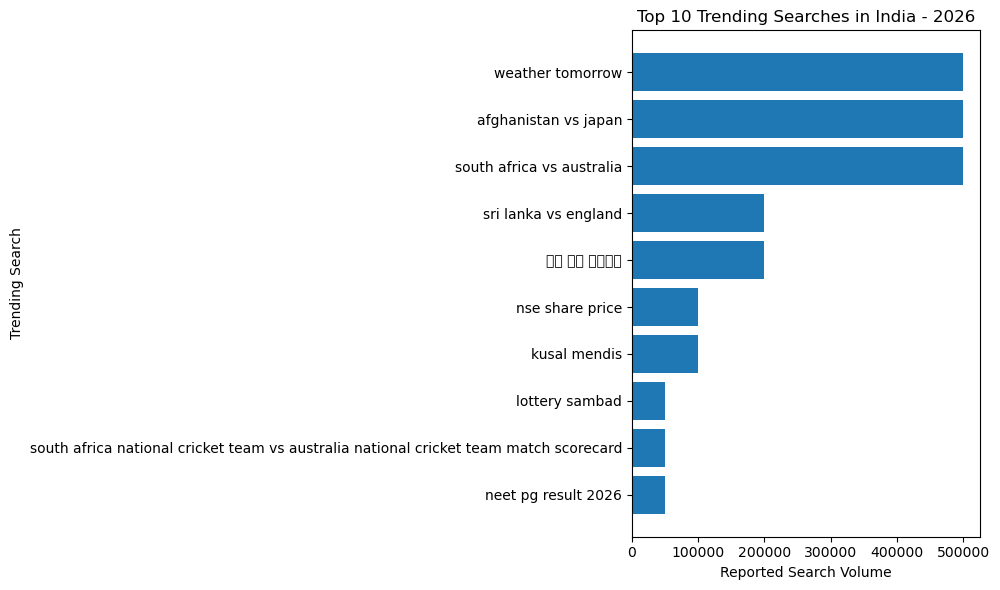

In [47]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Trends"],
    top_10["Search Volume Numeric"]
)

plt.title("Top 10 Trending Searches in India - 2026")
plt.xlabel("Reported Search Volume")
plt.ylabel("Trending Search")

plt.tight_layout()
plt.show()

In [48]:
longest_trends

,Trends,Search volume,Started,Ended,Trend breakdown,Explore link,Search Volume Numeric,Duration_Hours
14,wasim akram,20K+,2026-09-24 05:20:00-05:30,2026-09-24 22:40:00-05:30,wasim akram,./explore?q=wasim%20akram&geo=IN,20000.0,17.333333
16,arab gul,20K+,2026-09-24 05:40:00-05:30,2026-09-24 20:50:00-05:30,arab gul,./explore?q=arab%20gul&geo=IN,20000.0,15.166667
18,aaj ka mausam,20K+,2026-09-24 05:50:00-05:30,2026-09-24 18:20:00-05:30,"aaj ka mausam,weather patna",./explore?q=aaj%20ka%20mausam&geo=IN,20000.0,12.500000
24,morgan stanley,10K+,2026-09-24 04:50:00-05:30,2026-09-24 15:30:00-05:30,morgan stanley,./explore?q=morgan%20stanley&geo=IN,10000.0,10.666667
73,mirabai chanu,1K+,2026-09-24 03:50:00-05:30,2026-09-24 14:30:00-05:30,mirabai chanu,./explore?q=mirabai%20chanu&geo=IN,1000.0,10.666667
26,paradise movie rating,10K+,2026-09-24 06:40:00-05:30,2026-09-24 16:40:00-05:30,"paradise movie rating,paradise movie,the parad...",./explore?q=paradise%20movie%20rating&geo=IN,10000.0,10.000000
8,south africa national cricket team vs australi...,50K+,2026-09-24 13:10:00-05:30,2026-09-24 22:30:00-05:30,south africa national cricket team vs australi...,./explore?q=south%20africa%20national%20cricke...,50000.0,9.333333
39,saudi arabia vs kuwait,5K+,2026-09-23 23:10:00-05:30,2026-09-24 08:00:00-05:30,saudi arabia vs kuwait,./explore?q=saudi%20arabia%20vs%20kuwait&geo=IN,5000.0,8.833333
19,ఆంధ్ర ప్రదేశ్,20K+,2026-09-24 08:30:00-05:30,2026-09-24 17:00:00-05:30,"ఆంధ్ర ప్రదేశ్,వాతావరణం",./explore?q=%E0%B0%86%E0%B0%82%E0%B0%A7%E0%B1%...,20000.0,8.500000
33,nathan ellis,5K+,2026-09-24 14:30:00-05:30,2026-09-24 22:20:00-05:30,nathan ellis,./explore?q=nathan%20ellis&geo=IN,5000.0,7.833333


In [49]:
longest_trends_sorted = longest_trends.sort_values(
    "Duration_Hours"
)

/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3440123837.py:12: UserWarning: Glyph 3078 (\N{TELUGU LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3440123837.py:12: UserWarning: Matplotlib currently does not support Telugu natively.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3440123837.py:12: UserWarning: Glyph 3074 (\N{TELUGU SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3440123837.py:12: UserWarning: Glyph 3111 (\N{TELUGU LETTER DHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3440123837.py:12: UserWarning: Glyph 3149 (\N{TELUGU SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pm/l5bmycf516d_9c60m_wb2lp00000gn/T/ipykernel_17781/3440123837.py:12

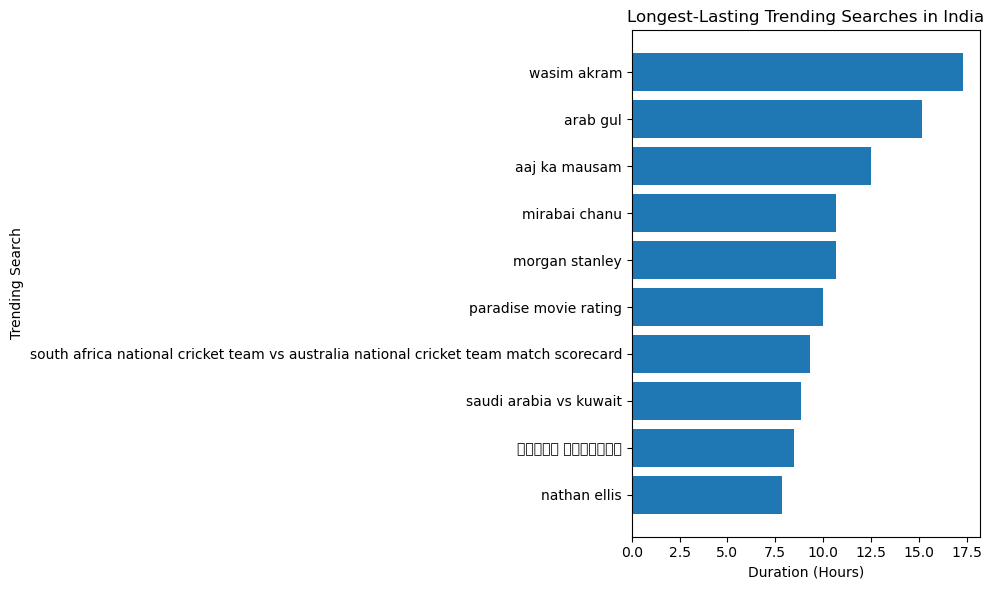

In [50]:
plt.figure(figsize=(10, 6))

plt.barh(
    longest_trends_sorted["Trends"],
    longest_trends_sorted["Duration_Hours"]
)

plt.title("Longest-Lasting Trending Searches in India")
plt.xlabel("Duration (Hours)")
plt.ylabel("Trending Search")

plt.tight_layout()
plt.show()

### Active and Ended Trends

This analysis compares trends that were still active with trends that had already ended at the time of data collection.

In [51]:
active_count = trending_df["Ended"].isna().sum()
ended_count = trending_df["Ended"].notna().sum()

print("Active trends:", active_count)
print("Ended trends:", ended_count)

Active trends: 23
Ended trends: 71


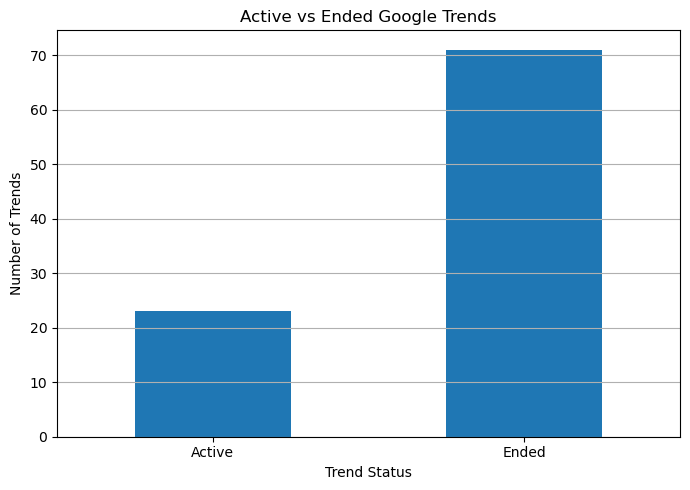

In [52]:
status_counts = pd.Series(
    {
        "Active": active_count,
        "Ended": ended_count
    }
)

plt.figure(figsize=(7, 5))

status_counts.plot(kind="bar")

plt.title("Active vs Ended Google Trends")
plt.xlabel("Trend Status")
plt.ylabel("Number of Trends")

plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## 17. Key Findings

The analysis of Google search trends in India during 2026 produced several important observations.

### 1. ChatGPT Search Interest

ChatGPT maintained the highest average search interest among the five selected keywords during the analyzed period. Its monthly average increased from 70.25 in January to 83.80 in August before declining to 78.00 in September.

### 2. Claude Search Interest

Claude showed a substantial increase in search interest during the analyzed period. Its monthly average increased from 2.00 in January to 13.25 in June and July. Although the percentage increase from January to September was large, the result is influenced by its relatively low January baseline.

### 3. Google Gemini Search Interest

Google Gemini showed relatively stable search interest throughout the period, with monthly averages remaining within a comparatively narrow range.

### 4. Python Search Interest

Python search interest remained relatively stable throughout the analyzed period, with moderate fluctuations between months.

### 5. Data Science Search Interest

The Data Science keyword maintained a value of 1.00 throughout the dataset. Because the value remained constant, correlation with the other keywords could not be calculated.

### 6. Correlation Analysis

The correlation analysis showed different relationships between the keywords. ChatGPT and Claude had a moderate positive correlation of approximately 0.49, while Claude and Python had a moderate negative correlation of approximately -0.54.

Correlation indicates how two variables move together and does not establish a causal relationship.

## 18. Limitations

There are several limitations to this analysis.

1. Google Trends provides relative search-interest values rather than exact search counts.

2. The analysis covers January to September 2026 because the dataset was collected during September 2026. October, November, and December data were therefore unavailable.

3. Google Trends values are normalized, so they should not be interpreted as the actual number of searches.

4. The multi-keyword comparison contains five keywords. Comparisons involving additional groups of keywords would require separate Google Trends queries and careful normalization.

5. The Trending Now dataset represents a snapshot of recent search activity and can change frequently.

6. Search interest does not necessarily represent user sentiment, preference, or actual usage of a technology.

7. Correlation between search-interest patterns does not imply that one keyword causes changes in another keyword.

## 19. Conclusion

This project analyzed Google search behavior in India during 2026 using Google Trends data. The analysis included both historical search-interest data for selected technology-related keywords and a separate Trending Now dataset representing recent search activity.

The historical analysis examined search-interest trends, monthly averages, peak values, weekly changes, percentage changes, and correlations between keywords. The results showed different search-interest patterns across ChatGPT, Google Gemini, Claude, Python, and Data Science.

The Trending Now analysis provided an additional view of current search activity by examining trending searches, reported search-volume ranges, active trends, ended trends, and trend duration.

Overall, the project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to collect, clean, analyze, visualize, and interpret real-world search-trend data.

---

## Project Note

This project was developed as a practical data-analysis project using Python and Google Trends data.

The analysis demonstrates data loading, cleaning, exploratory data analysis, statistical analysis, visualization, and interpretation of real-world search-trend data.